# Análise de Correlação — Vendas de uma Superloja (Superstore)

**Disciplina:** Machine Learning — Técnicas Especiais de Análise de Dados
**Aluno:** Eduardo Vitor Oliveira
**Professor:** Ricardo
**Data:** 18/09/2026
**Dataset:** [Superstore Dataset Final](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) — Kaggle

### Objetivo
Estudar o **grau de relacionamento estatístico** entre variáveis numéricas de um conjunto real de vendas de uma superloja (pedidos, quantidade, desconto, lucro), aplicando o **coeficiente de correlação de Pearson** e recursos visuais (heatmap e gráficos de dispersão com reta de tendência).

### O que é correlação?
Correlação é uma medida estatística que indica o grau e a direção da relação linear entre duas variáveis numéricas. O coeficiente varia entre **-1** e **1**:

- Próximo de **+1** → correlação **positiva forte** (quando uma variável sobe, a outra também sobe).
- Próximo de **-1** → correlação **negativa forte** (quando uma variável sobe, a outra desce).
- Próximo de **0** → **ausência de correlação linear** entre as variáveis.

> Importante: correlação não implica causalidade. Duas variáveis podem estar correlacionadas sem que uma seja causa da outra.


## 1. Obtenção do dataset

O dataset será baixado diretamente do Kaggle usando a API oficial. Para isso, é necessário ter um arquivo `kaggle.json` (Token de API), gerado em **Kaggle → Account → Create New API Token**.

In [ ]:
# Instala o pacote da API do Kaggle (já vem pré-instalado na maioria dos ambientes Colab, mas garantimos a versão)
!pip install -q kaggle

from google.colab import files
print("Selecione o arquivo kaggle.json baixado da sua conta Kaggle:")
uploaded = files.upload()


In [ ]:
# Configura as credenciais da API do Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Baixa e descompacta o dataset
!kaggle datasets download -d vivek468/superstore-dataset-final -p ./dados --unzip
!ls ./dados


> **Alternativa sem API do Kaggle:** caso não queira configurar o token, baixe o CSV manualmente em https://www.kaggle.com/datasets/vivek468/superstore-dataset-final, faça upload no Colab com `files.upload()` e ajuste o nome do arquivo na célula abaixo.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# O arquivo principal do dataset é o "Sample - Superstore.csv"
import glob
csv_path = glob.glob('./dados/*.csv')[0]
print("Arquivo carregado:", csv_path)

df = pd.read_csv(csv_path, encoding='latin1')
df.head(10)


Arquivo carregado: ./dados/Sample - Superstore.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


## 2. Conhecendo o dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.shape

(9994, 21)

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Análise visual de correlação

Vamos observar como pares de variáveis numéricas se relacionam usando `lmplot` (dispersão + reta de tendência).

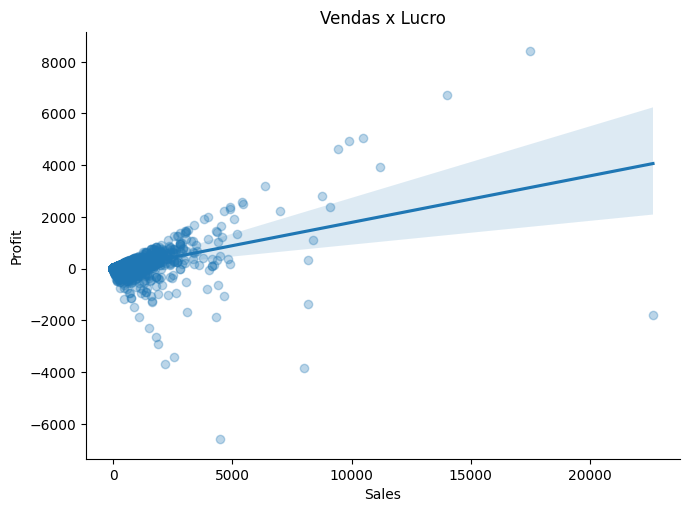

In [7]:
# Sales x Profit: espera-se uma correlação POSITIVA (mais venda tende a gerar mais lucro)
sns.lmplot(x="Sales", y="Profit", data=df, height=5, aspect=1.4,
           scatter_kws={'alpha':0.3})
plt.title("Vendas x Lucro")
plt.show()


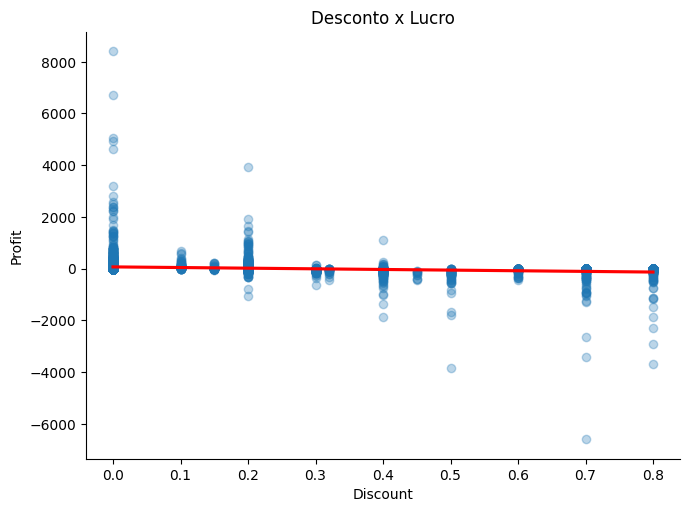

In [8]:
# Discount x Profit: espera-se uma correlação NEGATIVA (descontos maiores tendem a reduzir o lucro)
sns.lmplot(x="Discount", y="Profit", data=df, height=5, aspect=1.4,
           scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Desconto x Lucro")
plt.show()


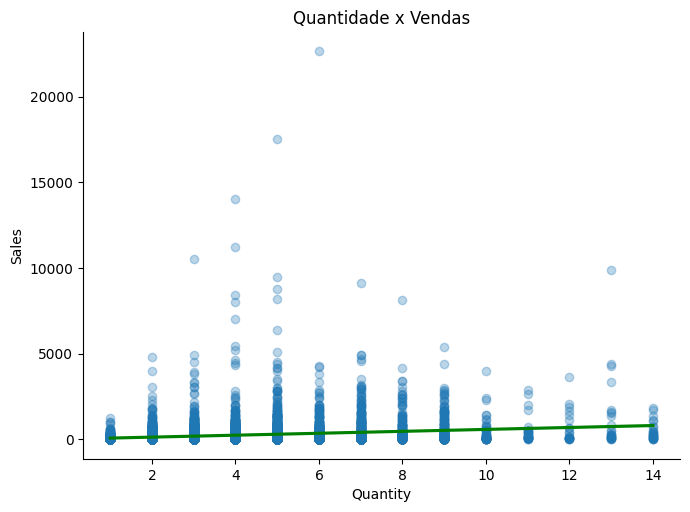

In [9]:
# Quantity x Sales: relação esperada mais fraca/neutra
sns.lmplot(x="Quantity", y="Sales", data=df, height=5, aspect=1.4,
           scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title("Quantidade x Vendas")
plt.show()


## 4. Coeficientes de correlação (Pearson)

In [10]:
colunas_numericas = ["Sales", "Quantity", "Discount", "Profit"]
df[colunas_numericas].corr()


,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


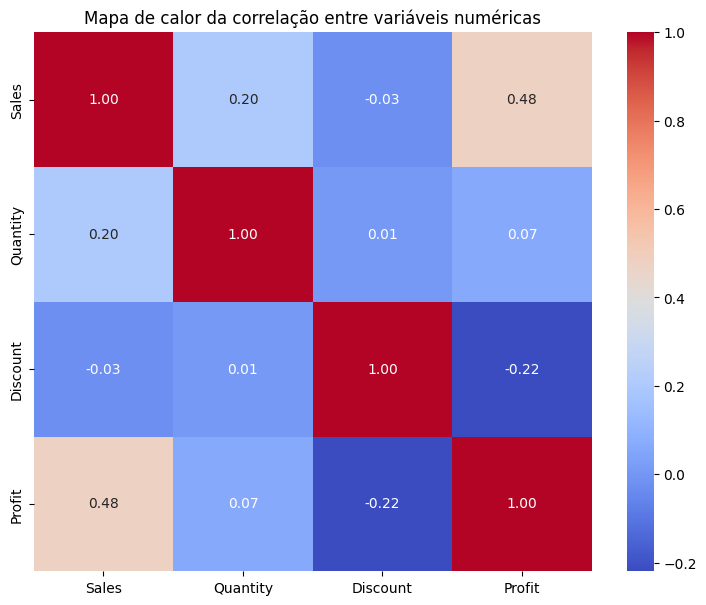

In [11]:
plt.rcParams["figure.figsize"] = (9, 7)
ax = sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor da correlação entre variáveis numéricas")
plt.show()


## 5. Conclusões

A análise foi feita sobre as **9.994 vendas** registradas no dataset. Os coeficientes de correlação obtidos foram:

| Par de variáveis | Correlação (Pearson) | Interpretação |
|---|---|---|
| Sales x Profit | **0,479** | Positiva moderada — vendas maiores tendem a gerar mais lucro, mas a relação está longe de ser perfeita (existem vendas grandes com pouco lucro, e vice-versa) |
| Discount x Profit | **-0,219** | Negativa fraca/moderada — quanto maior o desconto aplicado, menor tende a ser o lucro da venda, confirmando a intuição inicial |
| Quantity x Sales | 0,201 | Positiva fraca — a quantidade de itens vendidos tem pouca relação linear direta com o valor total da venda (faz sentido: produtos caros vendidos em pouca quantidade também geram vendas altas) |
| Quantity x Profit | 0,066 | Praticamente nula — a quantidade de itens, isoladamente, quase não explica o lucro |

**Principal insight de negócio:** o desconto tem uma correlação negativa com o lucro, mas não é a variável mais determinante — o valor da venda em si (`Sales`) importa mais. Isso sugere que a política comercial não deveria simplesmente banir descontos, e sim revisar em quais faixas de desconto o lucro começa a cair de forma mais acentuada (o gráfico de dispersão "Desconto x Lucro" mostra que, a partir de descontos por volta de 30-40%, boa parte das vendas passa a ter lucro negativo).
